# Task 1: Holdout Test-Set Error Implementation

Train Accuracy: 0.8791208791208791
Test Accuracy: 0.9035087719298246


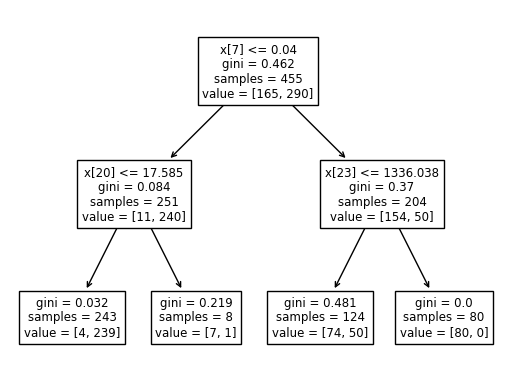

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import numpy as np

# Load and split data
data = load_breast_cancer()
X, y = data.data, data.target
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

X_train, X_test = X[indices[:train_size]], X[indices[train_size:]]
y_train, y_test = y[indices[:train_size]], y[indices[train_size:]]

# Train model
clf = DecisionTreeClassifier(max_depth=2, splitter="random", random_state=42)
clf.fit(X_train, y_train)

# Calculate accuracies
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
plot_tree(clf)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Test-Set Advantage:

1. Evaluates performance on unseen data
2. Avoids optimism bias from training data reuse
3. Better estimates generalization error

# Task 2: 1-NN Classifier Implementation

In [2]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

resub_acc = accuracy_score(y_train, knn.predict(X_train))
test_knn_acc = accuracy_score(y_test, knn.predict(X_test))

print("Resubstitution Accuracy:", resub_acc)
print("Test Accuracy:", test_knn_acc)

Resubstitution Accuracy: 1.0
Test Accuracy: 0.9035087719298246


Resubstitution Behavior:
1. Perfect training accuracy due to memorization
2. High variance leads to test performance gap
3. Demonstrates overfitting paradox


Test error better approximates true error ($ε_n$) because:
1. Uses independent data sample
2. Not biased by training memorization
3. Reflects real-world performance

# Task 3: 5-Fold Cross-Validation Implementation

In [3]:
n_folds = 5
fold_size = len(X) // n_folds
cv_accuracies = []

for fold in range(n_folds):
    val_idx = indices[fold*fold_size : (fold+1)*fold_size]
    train_idx = np.concatenate([indices[:fold*fold_size], 
                               indices[(fold+1)*fold_size:]])
    
    model = DecisionTreeClassifier(max_depth=2, splitter="random")
    model.fit(X[train_idx], y[train_idx])
    cv_accuracies.append(accuracy_score(y[val_idx], model.predict(X[val_idx])))

mean_cv = np.mean(cv_accuracies)
std_cv = np.std(cv_accuracies)  

print("Mean accuracy (Cross-Validation):", mean_cv)
print("Standard deviation (Cross-Validation):", std_cv)

Mean accuracy (Cross-Validation): 0.9008849557522124
Standard deviation (Cross-Validation): 0.01715992869881886


CV vs Holdout Difference:
1. Utilizes multiple data partitions
2. Reduces partition-specific bias
3. More efficient data usage

Variability Reduction:
1. Aggregates results from multiple splits
2. Less dependent on single random split
3. Stable performance estimate